<a href="https://www.kaggle.com/code/sonawanelalitsunil/korean-dramas-insights-ml-70?scriptVersionId=230634942" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/korean-dramas-dataset-eda/kdrama_DATASET.csv


## Korean Dramas Insights

## Explore trends, ratings, and genres in Korean dramas with this dataset.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/korean-dramas-dataset-eda/kdrama_DATASET.csv')

In [3]:
df.head()

,Rank,Title,Year of release,Number of Episodes,Rating,Description,Genre,Tags,Actors
0,#1,Move to Heaven,2021,10,9.2,Geu Roo is a young autistic man. He works for ...,"Life, Drama, Family","Autism, Uncle-Nephew Relationship, Death, Sava...","Lee Je Hoon, Tang Jun Sang, Hong Seung Hee, Ju..."
1,#2,Twinkling Watermelon,2023,16,9.2,"In 2023, high school student Eun Gyeol, a CODA...","Romance, Youth, Drama, Fantasy","Time Travel, Child From The Future, Sign Langu...","Ha Eun-Gyeol, Ha Yi-Chan, Choi Se-Kyung, Yoon ..."
2,#3,Moving,2023,20,9.1,"Kim Bong Seok, Jang Hui Su, and Lee Gang Hun, ...","Action, Thriller, Mystery, Supernatural","Graphic Violence, Supernatural Power, Multiple...","Ryu Seung Ryong, Han Hyo Joo, Zo In Sung"
3,#4,The Trauma Code: Heroes on Call,2025,8,9.1,"Baek Gang Hyeok, a genius trauma surgeon with ...","Action, Comedy, Drama, Medical","Surgeon Male Lead, Hospital Setting, Mentor-Me...","Ju Ji Hoon, Choo Young Woo, Ha Young, Yoon Gyu..."
4,#5,Flower of Evil,2020,16,9.1,Although Baek Hee Sung is hiding a dark secret...,"Thriller, Romance, Crime, Melodrama","Married Couple, Deception, Suspense, Family Se...","Lee Joon Gi, Moon Chae Won, Jang Hee Jin, Seo ..."


In [4]:
df.tail()

,Rank,Title,Year of release,Number of Episodes,Rating,Description,Genre,Tags,Actors
345,#346,Oh! Youngsim,2023,10,6.9,"Oh Young Sim, a 30-something TV variety show P...","Comedy, Romance","Childhood Acquaintances Reuniting, Producer Fe...","Song Ha Yoon, Lee Dong Hae, Lee Min Jae, Ryu H..."
346,#347,DNA Lover,2024,16,6.9,"So Jin, a genetic researcher who loves DNA, de...","Comedy, Romance, Melodrama","Medical Research, Medical, Columnist Female Le...","Choi Si Won, Jung In Sun, Jung Eugene, Lee Tae..."
347,#348,Our Love Triangle,2024,10,6.9,"Hae Rin, a university student, finds herself t...","Romance, Youth","Tsundere Male Lead, Ex Comes Back, Passionate ...","Gong Chan, Ahn Se Min, Kim Si Gyeong"
348,#349,The Brave Yong Su Jeong,2024,124,6.8,"Yong Su Jeong has a refreshing charm, which he...","Romance, Drama, Melodrama","Guest House Setting, Adoptive Father-Adoptive ...","Uhm Hyun Kyung, Seo Joon Young, Im Ju Eun, Kwo..."
349,#350,Goodbye Earth,2024,12,6.4,An asteroid is on course to crash into Earth i...,"Thriller, Psychological, Drama, Sci-Fi","Former Teacher Female Lead, Protective Female ...","Ahn Eun Jin, Yoo Ah In, Jeon Sung Woo, Kim Yoo..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                350 non-null    object 
 1   Title               350 non-null    object 
 2   Year of release     350 non-null    int64  
 3   Number of Episodes  350 non-null    int64  
 4   Rating              350 non-null    float64
 5   Description         350 non-null    object 
 6   Genre               350 non-null    object 
 7   Tags                350 non-null    object 
 8   Actors              350 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 24.7+ KB


In [6]:
df.describe()

,Year of release,Number of Episodes,Rating
count,350.000000,350.000000,350.000000
mean,2019.808571,18.254286,8.364857
std,3.713282,14.565962,0.454704
min,2003.000000,1.000000,6.400000
25%,2018.000000,12.000000,8.300000
50%,2020.000000,16.000000,8.400000
75%,2023.000000,16.000000,8.600000
max,2025.000000,133.000000,9.200000


In [7]:
df.isnull().sum()

Rank                  0
Title                 0
Year of release       0
Number of Episodes    0
Rating                0
Description           0
Genre                 0
Tags                  0
Actors                0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Rank                   object
Title                  object
Year of release         int64
Number of Episodes      int64
Rating                float64
Description            object
Genre                  object
Tags                   object
Actors                 object
dtype: object

In [10]:
df.shape

(350, 9)

In [11]:
df.columns

Index(['Rank', 'Title', 'Year of release', 'Number of Episodes', 'Rating',
       'Description', 'Genre', 'Tags', 'Actors'],
      dtype='object')

## Data visualizations

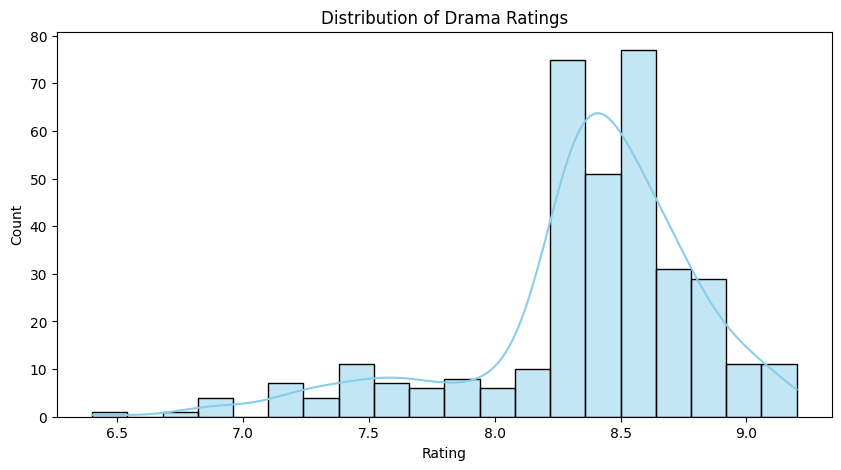

In [12]:
# Convert 'Year of release' to integer
df['Year of release'] = pd.to_numeric(df['Year of release'], errors='coerce')

# 1. Distribution of Ratings
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=20, kde=True, color='skyblue')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Drama Ratings')
plt.show()

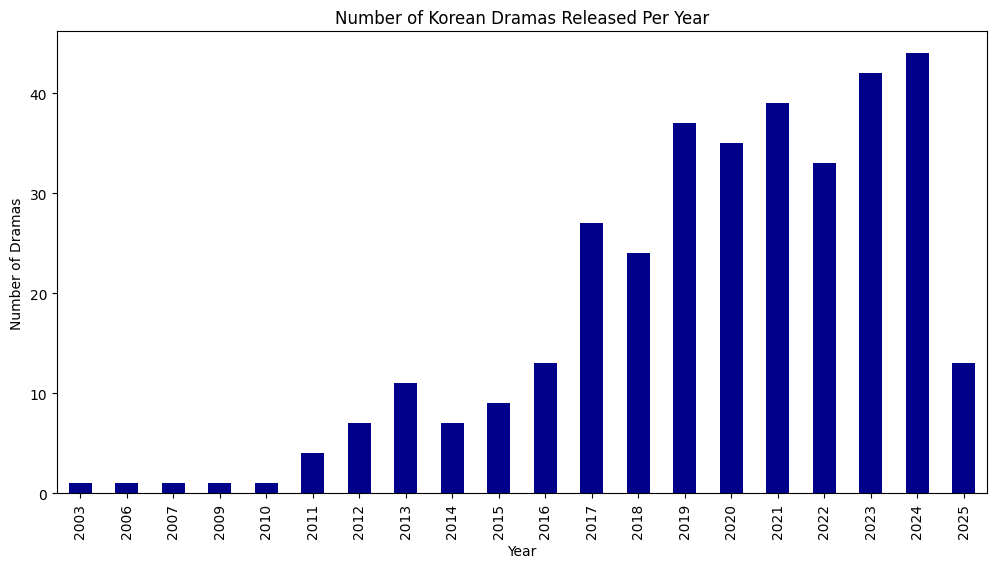

In [13]:
# 2. Number of Dramas Released Per Year
plt.figure(figsize=(12, 6))
df['Year of release'].value_counts().sort_index().plot(kind='bar', color='darkblue')
plt.xlabel('Year')
plt.ylabel('Number of Dramas')
plt.title('Number of Korean Dramas Released Per Year')
plt.show()

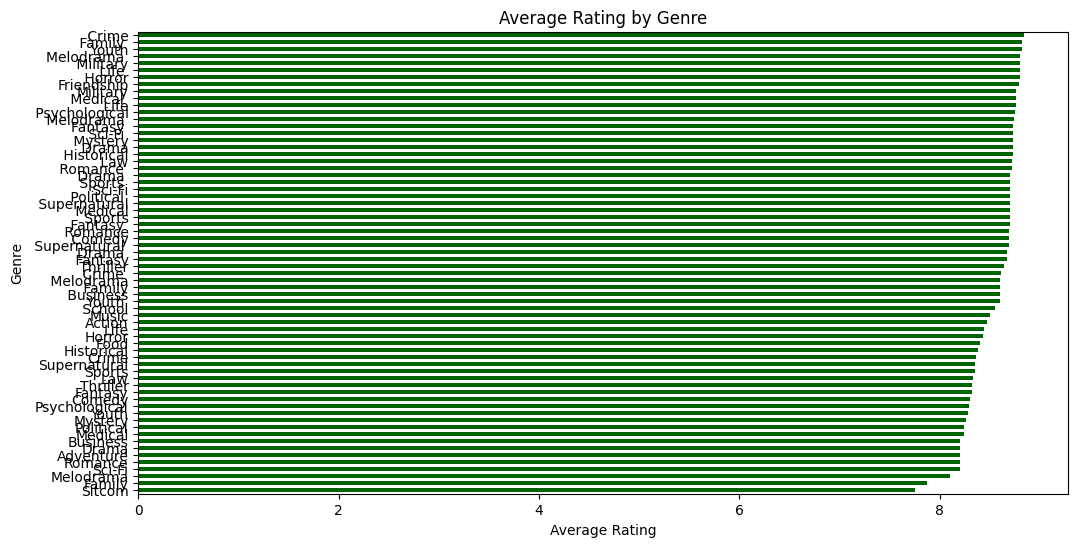

In [14]:
# 3. Average Rating by Genre
df_exploded = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')
genre_ratings = df_exploded.groupby('Genre')['Rating'].mean().sort_values()
plt.figure(figsize=(12, 6))
genre_ratings.plot(kind='barh', color='darkgreen')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.title('Average Rating by Genre')
plt.show()

In [15]:
from wordcloud import WordCloud
from collections import Counter

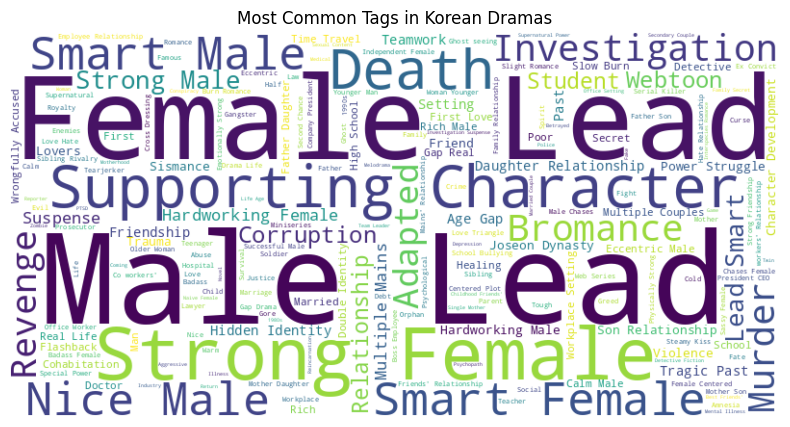

In [16]:
# 4. Most Common Tags Word Cloud
tags_text = ' '.join(df['Tags'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(tags_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Tags in Korean Dramas')
plt.show()

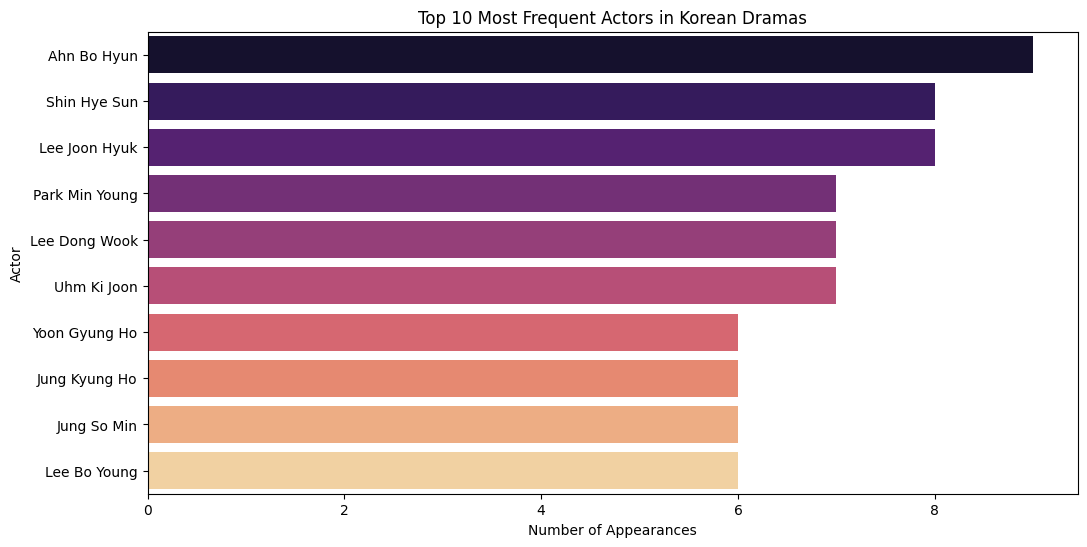

In [17]:
# 5. Top 10 Most Frequent Actors
actor_list = ', '.join(df['Actors'].dropna()).split(', ')
actor_counts = Counter(actor_list)
top_actors = pd.DataFrame(actor_counts.most_common(10), columns=['Actor', 'Count'])
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Actor', data=top_actors, palette='magma')
plt.xlabel('Number of Appearances')
plt.ylabel('Actor')
plt.title('Top 10 Most Frequent Actors in Korean Dramas')
plt.show()

## predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [19]:
# Convert 'Year of release' to integer
df['Year of release'] = pd.to_numeric(df['Year of release'], errors='coerce')

In [20]:
# Encode categorical columns
label_encoders = {}
categorical_columns = ['Title', 'Genre', 'Tags', 'Actors']
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [21]:
# Define features and target variable
X = df[['Year of release', 'Number of Episodes', 'Genre', 'Tags', 'Actors']]
y = df['Rating'] > df['Rating'].median()  # Binary classification based on median rating

In [22]:
# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Initialize classifiers
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree Classifier": DecisionTreeClassifier(),
    "Random Forest Classifier": RandomForestClassifier(),
    "Support Vector Classifier": SVC()
}

In [24]:
# Train and evaluate models
accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_results[name] = accuracy_score(y_test, y_pred) * 100

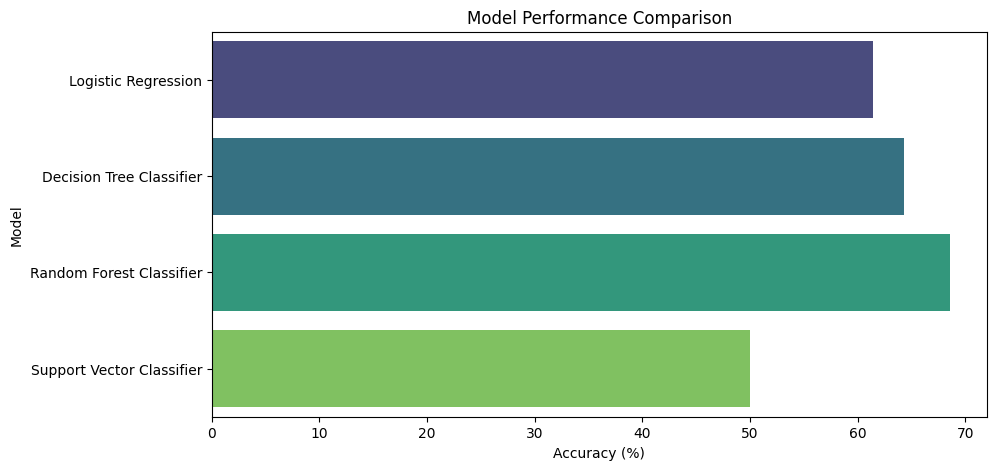

In [25]:
# Display accuracy results
accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy (%)'])
plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy (%)', y='Model', data=accuracy_df, palette='viridis')
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.title('Model Performance Comparison')
plt.show()

In [26]:
print(accuracy_df)

                       Model  Accuracy (%)
0        Logistic Regression     61.428571
1   Decision Tree Classifier     64.285714
2   Random Forest Classifier     68.571429
3  Support Vector Classifier     50.000000


## Thank you...pls upvote!!!!